# Decision Tree
## DecisionTree Classifier
* 선형과 비선형 관계 학습
* 해석이 쉽고 직관적인 모델
* 적은 전처리 (스케일링이 필요없음, 결측치는 필요)

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl  
mpl.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False  

from scipy import stats

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree

from sklearn.metrics import classification_report

### 와인 품종 분류
- N = 6497 * 4
- 설명 변수
    - alcohol : 알코올 도수 
    - sugar : 설탕 함류
    - ph : 산도(농도)
- 목표 변수
    - 레드와인 0, 화이트 와인 1

In [145]:
wine=pd.read_csv('./Data/wine.csv')
wine.shape

(6497, 4)

In [147]:
wine.head()

# data : 알코올 도수, 당도, PH(농도)
# target : 1(양성) 클래스는 화이트 와인
#          0(음성) 클래스는 레드 와인

,alcohol,sugar,ph,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [149]:
wine.info()               # 데이터 정보

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   ph       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [151]:
# wine.describe().T  
# wine[['alcohol', 'sugar', 'ph']].describe().T

wine.drop(columns='class').describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,6497.0,10.491801,1.192712,8.00,9.50,10.30,11.30,14.90
sugar,6497.0,5.443235,4.757804,0.60,1.80,3.00,8.10,65.80
ph,6497.0,3.218501,0.160787,2.72,3.11,3.21,3.32,4.01


In [153]:
wine['class'].value_counts(normalize=True)       # 화이트(1), 레드(0)  

class
1.0    0.753886
0.0    0.246114
Name: proportion, dtype: float64

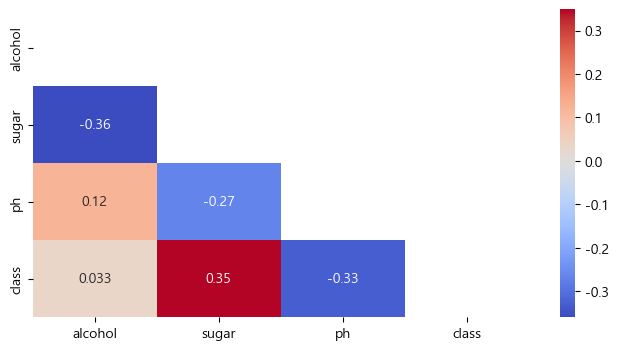

In [376]:
# wine.corr().round(2)    

plt.figure(figsize=(8, 4))
sns.heatmap(wine.corr(), 
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(wine.corr(), dtype=bool)))
plt.show()

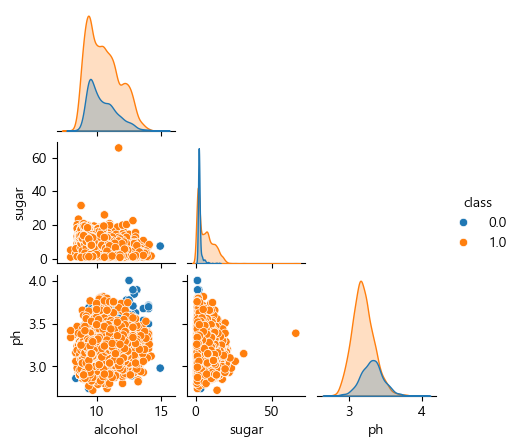

In [83]:
sns.pairplot(data=wine, corner=True, hue='class', height=1.5, aspect=1.0) 
plt.show()

In [380]:
wine.columns

Index(['alcohol', 'sugar', 'ph', 'class'], dtype='str')

In [85]:
# 설명, 목표 변수 설정
X=wine.iloc[:, :3]
Y=wine.iloc[:, -1]

X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)  
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((5197, 3), (5197,), (1300, 3), (1300,))

* 구조
  - Root Node : 모든 데이터 정보를 갖고 있음
  - Decision Node (부모) : 데이터를 분류할 질문들이 들어감
  - lef Node (자식): 의사 결정을 하지 않는 가장 마지막(노드 맨 끝)에 존재
  - depth : 깊이를 조정
* X : 분기 기준
  - 특성의 Threshold을 기준으로 불순도가 가장 작은 것 부터 선택
*  Y : 평가 기준
   - 수학적 계산 : 지니인덱스, 엔트로피(로그)
   - 불순도(gini)가 작아지는 방향 / ERROR (정보이득)

In [88]:
dt=DecisionTreeClassifier(random_state=42)        # X분기 시, 동점일 때 / class_weight='balanced'
dt.fit(X_train, Y_train)

print("학습:", dt.score(X_train, Y_train))       # 과대(overfitting) 적합 : 학습만 좋음
print("일반화:", dt.score(X_test, Y_test))

학습: 0.9978833942659227
일반화: 0.8653846153846154


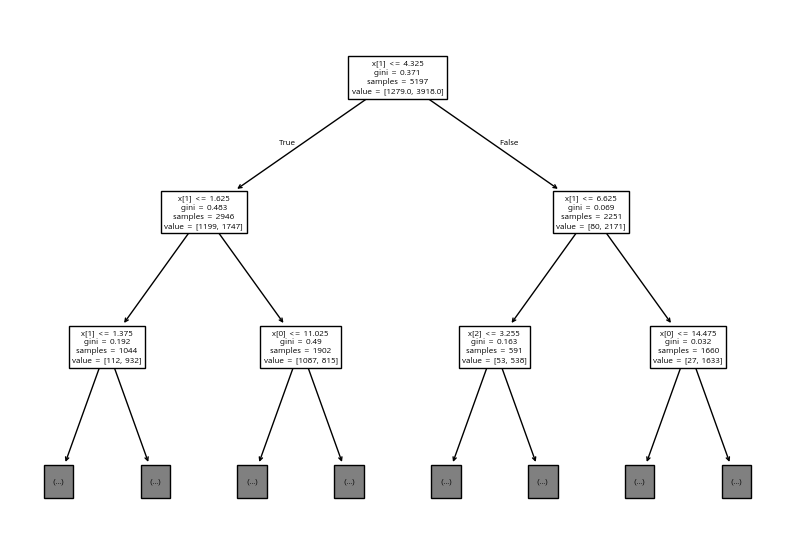

In [90]:
plt.figure(figsize=(10, 7))      # 너비가 10인치, 높이가 7인치
# plot_tree(dt)                 
plot_tree(dt, max_depth=2)
plt.show()

# 리프 노드 : 다수(분류), 평균(회귀)

### 지니 불순도
* 노드에서 데이터를 분할할 기준 정함

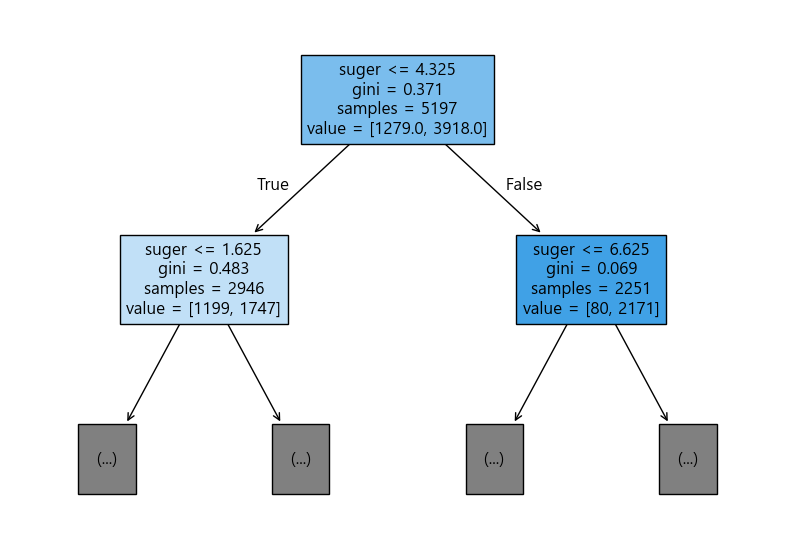

In [93]:
plt.figure(figsize=(10, 7))

# filled=True 지정하면 클래스마다 색깔를 부여한다.
plot_tree(dt, max_depth=1, filled=True, feature_names=['alochol', 'suger', 'ph'])   # X.columns
plt.show()

### 정지 규칙 (Stopping rule)
* 과대적합 방지
    - 노드내 최소 샘플 수 : min_samples_split
    - leaf 노드 개수 : min_samples_leaf
    - 최대 깊이 : max_depth

In [96]:
dt=DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, Y_train)

print("학습:", dt.score(X_train, Y_train))
print("일반화:", dt.score(X_test, Y_test))

학습: 0.8458726188185491
일반화: 0.8407692307692308


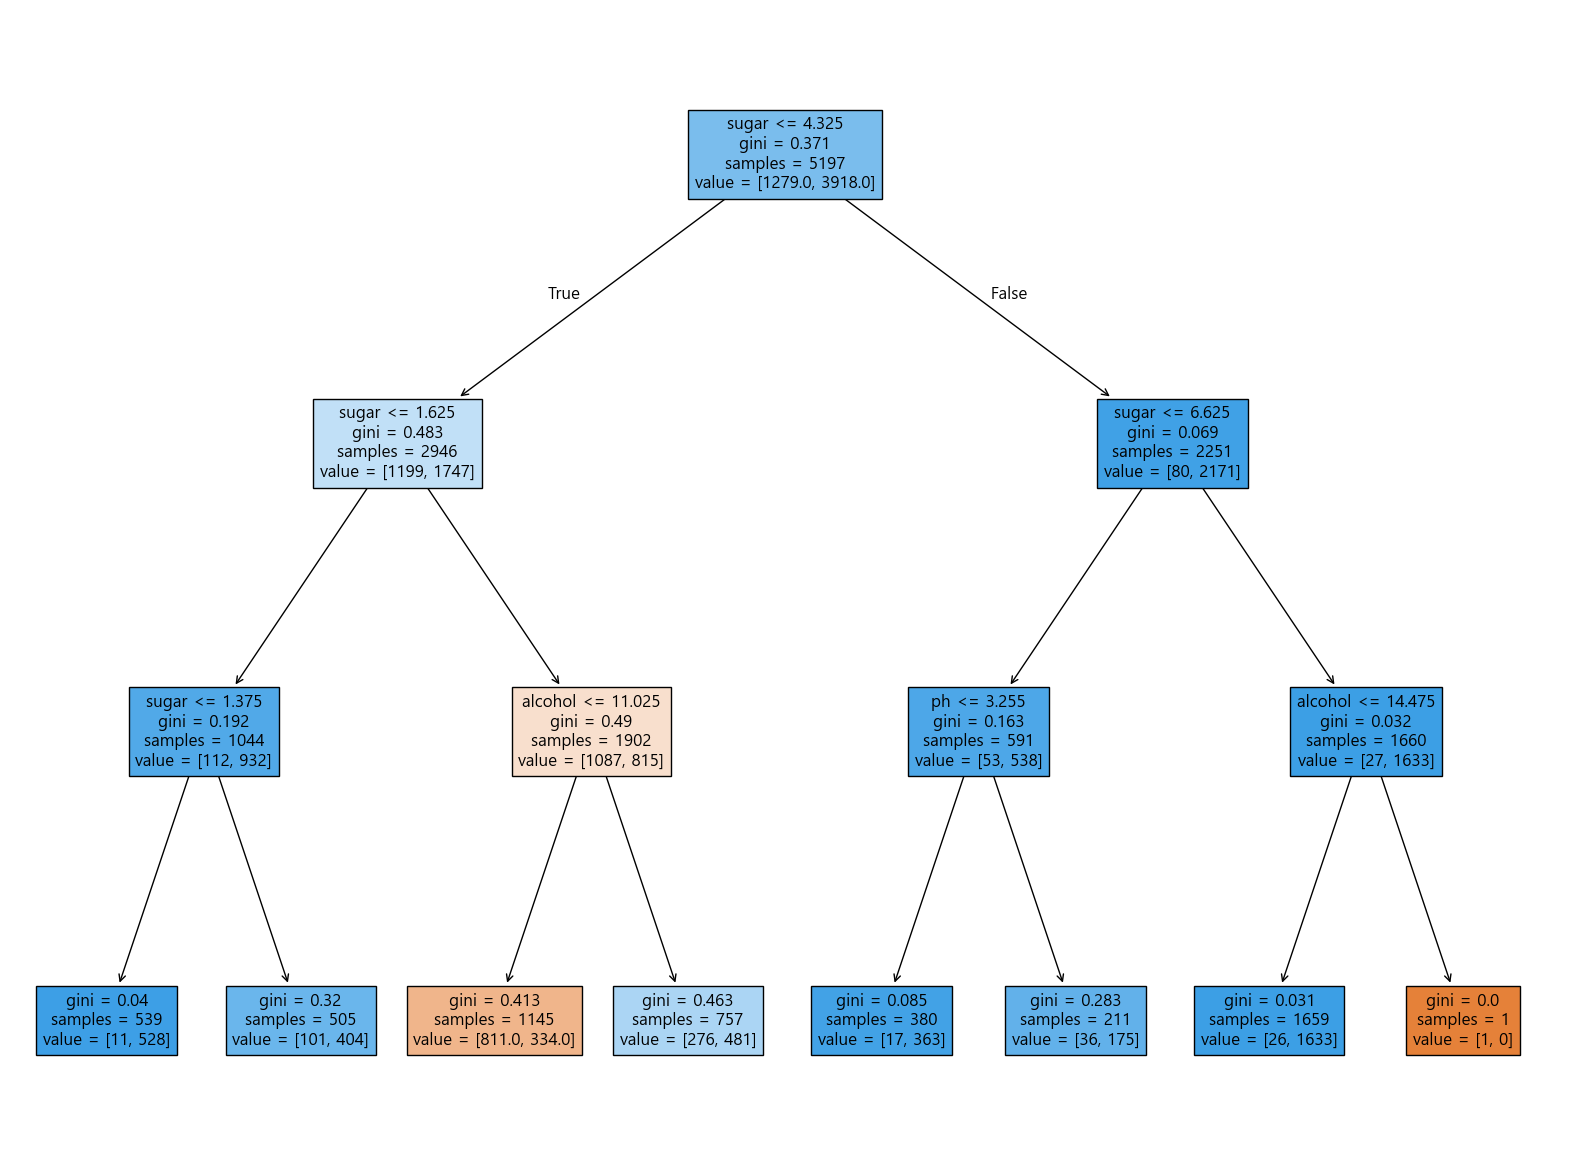

In [98]:
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'ph'])   # X.columns
plt.show()

In [100]:
dt.feature_importances_     # 특성 중요도 ('alochol', 'suger', 'ph')
                            # 전체 불순도 감소량을 100%  >> suger, alochol, ph

array([0.14086835, 0.85360568, 0.00552597])

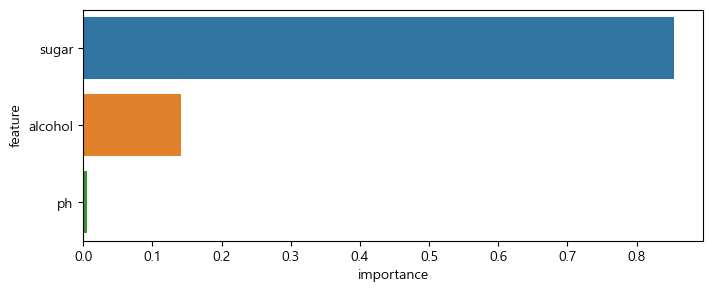

In [102]:
importance_df=pd.DataFrame({'feature': X.columns, 
                            'importance': dt.feature_importances_})
importance_df=importance_df.sort_values(by='importance', ascending=False)
importance_df

plt.figure(figsize=(8, 3))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature')
plt.show()

In [104]:
Y_test_pred=dt.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

         0.0       0.70      0.62      0.66       320
         1.0       0.88      0.91      0.90       980

    accuracy                           0.84      1300
   macro avg       0.79      0.77      0.78      1300
weighted avg       0.84      0.84      0.84      1300



## DecisionTree Regressor

### 데이터 전처리

In [13]:
dye=pd.read_csv('./Data/염색공정_5000_회귀.csv', encoding='cp949')
dye.shape

(5000, 11)

In [15]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '염색색차 DE'],
      dtype='str')

### 학습 및 평가
- 정지 규칙 과대적합 방지
    - 노드내 최소 샘플 수 : min_samples_split
    - leaf 노드 개수 : min_samples_leaf
    - 최대 깊이 : max_depth

In [18]:
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [20]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, random_state=42)

In [22]:
dt=DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, Y_train)

print("학습:", dt.score(X_train, Y_train))
print("일반화:", dt.score(X_test, Y_test))   

학습: 0.8913111101432412
일반화: 0.807043277431897


### 시각화

In [25]:
Y_test_pred=dt.predict(X_test)

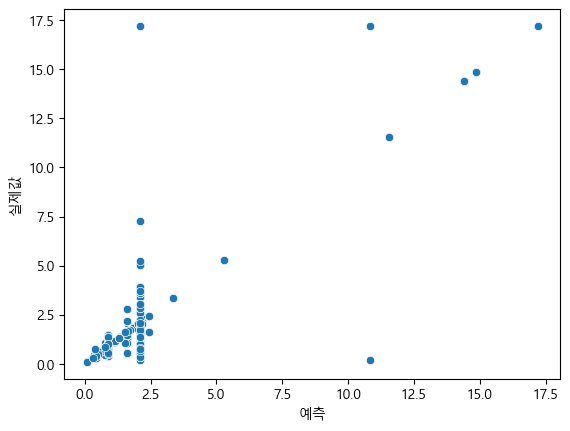

In [27]:
sns.scatterplot(x=Y_test_pred, y=Y_test)
plt.xlabel('예측') 
plt.ylabel('실제값') 
plt.show()

In [29]:
dt.feature_importances_          # 특성 중요도 : 모델 전체에서 어떤 변수가 예측에 얼마나 기여했는가

array([3.04782004e-02, 5.42562029e-01, 1.23498002e-01, 1.11025804e-01,
       5.05631262e-03, 9.04043509e-17, 3.24808591e-17, 2.75760748e-07,
       1.87379375e-01, 2.46164643e-16])

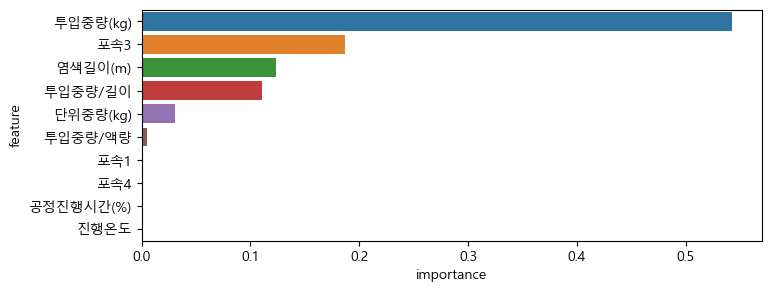

In [31]:
importance_df=pd.DataFrame({'feature': X.columns, 
                            'importance': dt.feature_importances_})
importance_df=importance_df.sort_values(by='importance', ascending=False)
importance_df

plt.figure(figsize=(8, 3))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature')
plt.show()

In [ ]:
!pip install shap==0.46.0

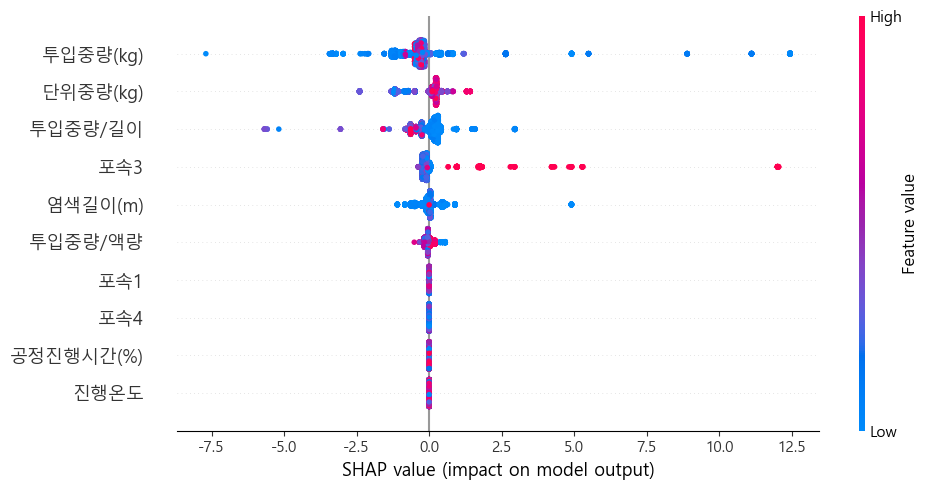

In [128]:
import shap   

# SHAP(SHapley Additive exPlanations) : 모델이 왜 이런 예측을 했는지 각 변수의 기여도를 설명하는 방법 (불량률 원인)
# TreeExplainer / LinearExplainer / KernelExplainer (KNN 등등) / DeepExplainer

exp=shap.TreeExplainer(dt)     # 트리 익스플레이너
shap_values=exp.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_size=(10, 5))

# 모델 최적화
* 교차검증, 하이퍼파라미터

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl  
mpl.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus']=False

# 전처리 부분
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

# 모델
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# HyperParameter
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

from scipy.stats import uniform, randint

## 교차검증

In [49]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
dye.shape

(5000, 11)

In [51]:
dye.columns

Index(['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '공정진행시간(%)',
       '진행온도', '포속1', '포속3', '포속4', '불량여부'],
      dtype='str')

In [53]:
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

### 학습
- 학습: 80%, 테스트: 20%

In [56]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)  

In [58]:
print("전체 데이터:", dye.shape)
print("학습 데이터:", X_train.shape)     
print("데스트 데이터:", X_test.shape)

전체 데이터: (5000, 11)
학습 데이터: (4000, 10)
데스트 데이터: (1000, 10)


### 검증 
- 학습: 80%
    - 학습: 60%, 테스트: 20%
- 출력 결과
    - fit_time : 모델 학습에 소요된 시간
    - score_time :  테스트 데이터에 대한 점수를 계산하는 데 걸린 시간
    - test_score : 데이터에 대해 모델의 성능을 평가한 정확도

In [67]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)   # 학습
X_test_scaled=scaler.transform(X_test)

knn=KNeighborsClassifier()
knn.fit(X_train_scaled, Y_train)

scores=cross_validate(knn, X_train_scaled, Y_train, 
                      cv=5, 
                      n_jobs=-1,                   # CPU코어 다 사욯하겠다.
                      return_train_score=True)     # 훈련, 검증 세트 대한 점수도 반환  / 기본값 False (test 반환)
  
scores

# 5-fold 교차 검증을 사용하여 모델 평가 / 데이터 4000개 기준 4000*5=20000 학습
# v_score=cross_validate(knn, X_train_scaled, Y_train, cv=5, scoring=['f1', 'precision', 'recall'])   
# v_score  >> 굳히 할 필요 없는 gs, rs 기본적으로 포함

{'fit_time': array([0.02005148, 0.01805782, 0.02006483, 0.01804209, 0.01904964]),
 'score_time': array([0.11832738, 0.12032104, 0.12132215, 0.15604329, 0.15303445]),
 'test_score': array([0.92   , 0.9325 , 0.94125, 0.94625, 0.92125]),
 'train_score': array([0.965    , 0.96375  , 0.9678125, 0.968125 , 0.9640625])}

### 평가

In [69]:
print("학습:", knn.score(X_train_scaled, Y_train))
print("일반화:", knn.score(X_test_scaled, Y_test), "\n")

print("학습 교차 검증 평균:", scores['train_score'].mean())
print("일반화 교차 검증 평균:", scores['test_score'].mean())

학습: 0.9705
일반화: 0.961 

학습 교차 검증 평균: 0.9657500000000001
일반화 교차 검증 평균: 0.93225


## HyperParameterTuning
* 모델 파라미터 : 머신러닝 모델이 학습하는 파라미터
* 하이퍼파라미터 : 모델이 학습할 수 없어서 사용자가 지정하는 것
  - 클래스나 매개변수로 표현
  - 작업은 라이브러리가 제공하는 기본 값으로 사용
  - 그 다음 검증 세트의 점수나 교차 검증을 통해서 매개변수를 조금씩 바꿈
  - 모델 마다 매개 변수 적게 1~2개, 많게는 5~6개 

### GridSerach
* 하이퍼파라미터 탐색과 교차 검증을 한번에 수행 <br>
  (하이퍼파라미터 범위 설정, 탐색 실행, 최적 조합 선택)
* 사용 방법
  - 하이퍼파라미터 범위 설정
  - 탐색 실행 (교차 검증)
  - 최적 조합

In [130]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [132]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#### KNN

In [135]:
# KNeighborsClassifier().get_params()

In [137]:
# 모델 학습
# 1) 탐색할 파라미터 그리드 설정
params={'n_neighbors': np.arange(5, 30, 6),      # np.arange(5, 70, 6) 시간 올려 걸림
        'p': [1, 2],                             # 1=맨해튼, 2=유클리드
        'weights': ['uniform', 'distance'],      # 거리 가중
        'algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'leaf_size': np.arange(20, 51, 10)}      # 트리 기반 알고리즘일 때만 적용
                                                 # 트리에서 더 이상 분할되지 않는 노드 np.arange(20, 51, 10)
    
# 2) GridSearchCV 초기화
# gs=GridSearchCV(KNeighborsClassifier(), params) 
# params=5×2×2×4×4=320 / 320×4000=1280000*5=6400000  학습
gs=GridSearchCV(KNeighborsClassifier(), params, cv=5, n_jobs=-1)   
gs.fit(X_train_scaled, Y_train)  

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['ball_tree', 'kd_tree', ...], 'leaf_size': array([20, 30, 40, 50]), 'n_neighbors': array([ 5, 11, 17, 23, 29]), 'p': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [138]:
# 3) GridSearchCV를 통해 최적의 파라미터 탐색
print("최적의 매개변수:", gs.best_params_)       # 최적의 하이퍼파라미터 조합 
print("최적의 교차검증점수:", gs.best_score_)    # 교차 검증으로 얻어진 평균 점수  

최적의 매개변수: {'algorithm': 'ball_tree', 'leaf_size': 20, 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
최적의 교차검증점수: 0.975


In [139]:
# 4) 테스트 데이터로 최적 모델 평가  
knn_best=gs.best_estimator_                       # 최적의 하이퍼파라미터 설정으로 학습된 모델을 반환
print("최적의 테스트 점수:", knn_best.score(X_test_scaled, Y_test))

최적의 테스트 점수: 0.984


In [142]:
Y_test_pred=gs.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       848
           1       0.95      0.95      0.95       152

    accuracy                           0.98      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000



#### DecisionTree
* criterion='gini': 분할 기준을 지정. "gini(속도 빠름)" 또는 "entropy" 
* max_depth=None: 트리의 최대 깊이를 제한 
* min_samples_split=2: 노드를 분할하기 위한 최소 샘플 수 
* min_samples_leaf=1: 리프 노드에 있어야 할 최소 샘플 수 
* min_impurity_decrease=0.0: 분할 후 불순도 감소량이 지정된 값보다 큰 경우 (0보다 커야 함) <br><br>
* max_features='auto' 모든 특성: 각 노드에서 분할에 사용할 최대 특성 수 
* max_leaf_nodes=None: split 후보 feature 수 제한
* min_impurity_split=None: 노드가 분리(split)되기 위해 필요한 최소 불순도 임계값

In [108]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [110]:
# DecisionTreeClassifier().get_params()

In [112]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# 1) 탐색할 파라미터 그리드 설정   
params={'max_depth': [5, 10, 15, 20],                     # np.arange(5, 21, 5) / 트리의 최대 깊이                            
        'min_samples_split': [2, 20, 50, 100],            # 노드 분할에 필요한 최소 샘플수            
        'min_samples_leaf': [1, 5, 10, 20],               # 리프 노드에 있어야 할 최소 샘플 수                
        'min_impurity_decrease': [0.0, 0.0001, 0.0005]}   # 분할 후 불순도 감소량이 지정된 값보다 큰 경우 (0보다 커야 함)

# 2) GridSearchCV 초기화
gs=GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=5, n_jobs=-1)
gs.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_impurity_decrease': [0.0, 0.0001, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [113]:
# 3) GridSearchCV를 통해 최적의 파라미터 탐색
print(gs.best_params_)             # 최적의 하이퍼파라미터 조합
print(gs.best_score_)              # 교차 검증으로 얻어진 평균 점수  

{'max_depth': 15, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.9952500000000001


In [114]:
# 4) 테스트 데이터로 최적 모델 평가
dt_best=gs.best_estimator_         # 최적의 하이퍼파라미터 설정으로 학습된 모델을 반환
print(dt_best.score(X_test, Y_test))    

0.994


In [115]:
Y_test_pred=gs.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       848
           1       0.98      0.98      0.98       152

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



### RandomSearch
- 그리드 서치 : 사전에 정의된 값들의 조합을 모두 시도하여 최적의 조합을 찾는다.
  - 하이퍼파라미터 범위가 크고 계산 시간이 중요한 경우
- 랜덤 서치 : 하이퍼파라미터 공간에서 무작위로 값을 선택하여 조합을 만든다.
  - 하이퍼파라미터가 제한적이고 모든 조합을 철저히 확인해야 할 경우

#### KNN

In [188]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [192]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# 1) 탐색할 파라미터 랜덤 설정
params={'n_neighbors': np.arange(5, 30, 6),                   # 이웃 수
        'p': [1, 2],                                         # 거리 계산 방식 (1: 맨해튼, 2: 유클리드)
        'weights': ['uniform', 'distance'],                  # 가중치 부여 방식
        'algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'leaf_size': randint(20, 50)}                       # 트리 기반 알고리즘일 때만 적용

# 2) RandomizedSearchCV 초기화  n_iter=10개의 조합을 무작위로 선택
rs=RandomizedSearchCV(KNeighborsClassifier(), params, n_iter=10, n_jobs=-1, random_state=42)
rs.fit(X_train_scaled, Y_train)  

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'algorithm': ['ball_tree', 'kd_tree', ...], 'leaf_size': <scipy.stats....00244E2156360>, 'n_neighbors': array([ 5, 11, 17, 23, 29]), 'p': [1, 2], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [194]:
# 3) RandomizedSearchCV 통해 최적의 파라미터 탐색
print("최적의 매개변수:", rs.best_params_)       
print("최적의 교차검증점수:", rs.best_score_)  

최적의 매개변수: {'algorithm': 'ball_tree', 'leaf_size': 31, 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
최적의 교차검증점수: 0.9684999999999999


In [196]:
knn_best=rs.best_estimator_    
print(knn_best.score(X_test_scaled, Y_test))

0.976


In [198]:
Y_test_pred=rs.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       848
           1       0.93      0.91      0.92       152

    accuracy                           0.98      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.98      0.98      0.98      1000



#### DecisionTree

In [235]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [251]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# 모델 학습
# 1) 탐색할 파라미터 랜덤 설정
params={'max_depth': randint(5, 20),                        # 트리의 최대 깊이
        'min_samples_split': randint(2, 100),               # 노드 분할에 필요한 최소 샘플수 
        'min_samples_leaf': randint(1, 21),                 # 리프 노드에 있어야 할 최소 샘플 수 
        'min_impurity_decrease' : uniform(0.0, 0.0005)}     # 분할 후 불순도 감소량이 지정된 값보다 큰 경우 (0보다 커야 함)
                                                            # 해당 노드는 더 이상 분할 (균등분포)
      
# 2) RandomizedSearchCV 초기화  n_iter=100개의 조합을 무작위로 선택
rs=RandomizedSearchCV(DecisionTreeClassifier(random_state=1234), params, n_iter=100, n_jobs=-1, random_state=42)   
rs.fit(X_train, Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...om_state=1234)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001DE66AFB6E0>, 'min_impurity_decrease': <scipy.stats....001DE66FB63F0>, 'min_samples_leaf': <scipy.stats....001DE66FB5BB0>, 'min_samples_split': <scipy.stats....001DE66DBC680>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User G

In [253]:
# 3) RandomizedSearchCV 통해 최적의 파라미터 탐색
print(rs.best_params_)    # 최적의 하이퍼파라미터 조합
print(rs.best_score_)     # 교차 검증으로 얻어진 평균 점수  

{'max_depth': 12, 'min_impurity_decrease': 0.00036450358402049366, 'min_samples_leaf': 1, 'min_samples_split': 6}
0.99325


In [255]:
# 4) 테스트 데이터로 최적 모델 평가
rs_best=rs.best_estimator_
print(rs_best.score(X_test, Y_test))

0.988


In [257]:
Y_test_pred=rs.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       848
           1       0.95      0.97      0.96       152

    accuracy                           0.99      1000
   macro avg       0.97      0.98      0.98      1000
weighted avg       0.99      0.99      0.99      1000



In [61]:
# End of ---------------------------------------------------------------------